In [1]:
import os
import numpy as np
import tensorflow as tf
import cv2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import TimeDistributed, Conv2D, MaxPooling2D, Flatten, LSTM, Dense, Dropout
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, Callback
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, roc_curve, auc

In [ ]:
def load_npy_sequences(file_paths, image_size=(64, 64), sequence_length=10):
    data = []
    labels = []

    for file_path in file_paths:
        with open(file_path, 'r') as f:
            lines = f.readlines()

        for line in lines:
            npy_path = line.strip()
            npy_path = f"./all_flows/{npy_path}.npy"
            if not os.path.exists(npy_path):
                print(f"[WARN] NPY path does not exist: {npy_path}")
                continue

            folder_name = os.path.basename(os.path.dirname(npy_path))
            label = 1 if "Normal_Videos_event" in folder_name else 0

            video_data = np.load(npy_path)
            
            resized_frames = [cv2.resize(frame, image_size) for frame in video_data]
            resized_frames = np.array(resized_frames)

            if resized_frames.shape[0] < sequence_length:
                continue

            for i in range(0, resized_frames.shape[0] - sequence_length + 1, sequence_length):
                sequence = resized_frames[i:i + sequence_length]
                sequence = np.expand_dims(sequence, axis=-1)
                data.append(sequence)
                labels.append(label)

    data = np.array(data)
    labels = np.array(labels)
    return data, labels


In [ ]:
def augment_data(data, labels, target_size=800, sequence_length=10):
    augmented_data = []
    augmented_labels = []
    datagen = ImageDataGenerator(rotation_range=20, width_shift_range=0.2, height_shift_range=0.2, zoom_range=0.2)

    anomaly_indices = np.where(labels == 1)[0]
    normal_indices = np.where(labels == 0)[0]

    if len(anomaly_indices) == 0:
        print("[ERROR] No abnormal samples found for augmentation.")
        return data, labels

    for idx in anomaly_indices:
        sequence = data[idx]
        augmented_data.append(sequence)
        augmented_labels.append(1)

        for _ in range((target_size - len(anomaly_indices)) // len(anomaly_indices) + 1):
            augmented_sequence = []
            for frame in sequence:
                frame = frame.reshape((1,) + frame.shape)
                iterator = datagen.flow(frame, batch_size=1)
                augmented_frame = next(iterator)[0]
                augmented_sequence.append(augmented_frame.reshape(sequence.shape[1:3] + (1,)))

            augmented_data.append(np.array(augmented_sequence))
            augmented_labels.append(1)

            if len(augmented_data) >= target_size:
                break
        if len(augmented_data) >= target_size:
            break

    np.random.shuffle(normal_indices)
    downsampled_normal_indices = normal_indices[:target_size]

    for idx in downsampled_normal_indices:
        augmented_data.append(data[idx])
        augmented_labels.append(0)

    final_data = np.array(augmented_data)
    final_labels = np.array(augmented_labels)

    return final_data, final_labels


In [ ]:
file_paths = ['./splits/train_001.txt', './splits/test_001.txt']
data, labels = load_npy_sequences(file_paths)

unique, counts = np.unique(labels, return_counts=True)
print("Initial label distribution:", dict(zip(unique, counts)))

balanced_data, balanced_labels = augment_data(data, labels, target_size=800)

unique, counts = np.unique(balanced_labels, return_counts=True)
print("Label distribution after augmentation:", dict(zip(unique, counts)))

normal_indices = np.where(balanced_labels == 0)[0]
abnormal_indices = np.where(balanced_labels == 1)[0]

if len(abnormal_indices) == 0:
    raise ValueError("[ERROR] No abnormal samples available for training and validation after augmentation.")

train_normal_indices, val_normal_indices = train_test_split(normal_indices, test_size=0.3, random_state=42)
train_abnormal_indices, val_abnormal_indices = train_test_split(abnormal_indices, test_size=0.3, random_state=42)

train_indices = np.concatenate([train_normal_indices, train_abnormal_indices])
val_indices = np.concatenate([val_normal_indices, val_abnormal_indices])

X_train = balanced_data[train_indices]
y_train = balanced_labels[train_indices]
X_val = balanced_data[val_indices]
y_val = balanced_labels[val_indices]

# Print validation set class distribution
unique, counts = np.unique(y_val, return_counts=True)
print("Validation set class distribution:", dict(zip(unique, counts)))


Initial label distribution: {0: 1950, 1: 150}
Label distribution after augmentation: {0: 800, 1: 800}
Validation set class distribution: {0: 240, 1: 240}


In [ ]:
def create_lstm_cnn_model(sequence_length=10, image_size=(64, 64), channels=1):
    model = Sequential()

    model.add(TimeDistributed(Conv2D(32, (3, 3), activation='relu', padding='same'),
                              input_shape=(sequence_length, image_size[0], image_size[1], channels)))
    model.add(TimeDistributed(MaxPooling2D((2, 2))))
    model.add(TimeDistributed(Conv2D(64, (3, 3), activation='relu', padding='same')))
    model.add(TimeDistributed(MaxPooling2D((2, 2))))
    model.add(TimeDistributed(Flatten()))

    model.add(LSTM(10, return_sequences=False, kernel_regularizer=tf.keras.regularizers.l2(0.01)))
    model.add(Dropout(0.5))
    model.add(Dense(1, activation='sigmoid', kernel_regularizer=tf.keras.regularizers.l2(0.01)))

    return model

model = create_lstm_cnn_model()
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001), 
              loss='binary_crossentropy', 
              metrics=['accuracy', tf.keras.metrics.Recall()])

In [ ]:
early_stopping = EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True, mode='max')

class CustomEarlyStopping(Callback):
    def __init__(self, target_accuracy=0.98):
        super(CustomEarlyStopping, self).__init__()
        self.target_accuracy = target_accuracy

    def on_epoch_end(self, epoch, logs=None):
        val_accuracy = logs.get('val_accuracy')
        if val_accuracy is not None and val_accuracy >= self.target_accuracy:
            print(f"\n[INFO] Reached {self.target_accuracy * 100}% validation accuracy, stopping training...")
            self.model.stop_training = True

custom_early_stopping = CustomEarlyStopping(target_accuracy=0.98)

try:
    with tf.device('/GPU:0'):
        history = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=30, batch_size=32,
                            callbacks=[early_stopping, custom_early_stopping])
except RuntimeError as e:
    print("[WARN] GPU is not available, falling back to CPU")
    history = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=30, batch_size=32,
                        callbacks=[early_stopping, custom_early_stopping])


Epoch 1/30
35/35 [==============================] - 12s 297ms/step - loss: 1.3364 - accuracy: 0.5027 - recall: 0.1304 - val_loss: 1.1697 - val_accuracy: 0.5000 - val_recall: 0.0000e+00
Epoch 2/30
35/35 [==============================] - 10s 300ms/step - loss: 1.0581 - accuracy: 0.5964 - recall: 0.2696 - val_loss: 0.9584 - val_accuracy: 0.8500 - val_recall: 0.7250
Epoch 3/30
35/35 [==============================] - 10s 299ms/step - loss: 0.8930 - accuracy: 0.7098 - recall: 0.5214 - val_loss: 0.8313 - val_accuracy: 0.8583 - val_recall: 0.7417
Epoch 4/30
35/35 [==============================] - 11s 307ms/step - loss: 0.7882 - accuracy: 0.6929 - recall: 0.5250 - val_loss: 0.7381 - val_accuracy: 0.8292 - val_recall: 0.8500
Epoch 5/30
35/35 [==============================] - 11s 307ms/step - loss: 0.6607 - accuracy: 0.8232 - recall: 0.8250 - val_loss: 0.5211 - val_accuracy: 0.8833 - val_recall: 0.8250
Epoch 6/30
35/35 [==============================] - 10s 294ms/step - loss: 0.4942 - accurac

In [ ]:
y_pred_prob = model.predict(X_val)
threshold = 0.5
y_pred = (y_pred_prob > threshold).astype("int32")

accuracy = accuracy_score(y_val, y_pred)
precision = precision_score(y_val, y_pred, zero_division=1)
recall = recall_score(y_val, y_pred, zero_division=1)
f1 = f1_score(y_val, y_pred, zero_division=1)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

# Check if both classes are present in y_val before calculating AUC
if len(np.unique(y_val)) > 1:
    auc_score = roc_auc_score(y_val, y_pred_prob)
    print(f"AUC: {auc_score:.4f}")
else:
    print("[WARN] AUC score cannot be calculated because only one class is present in y_val.")

15/15 [==============================] - 1s 64ms/step
Accuracy: 0.9104
Precision: 0.9950
Recall: 0.8250
F1 Score: 0.9021
AUC: 0.9262


In [ ]:
model.save('lstm_cnn_anomaly_detection.keras')

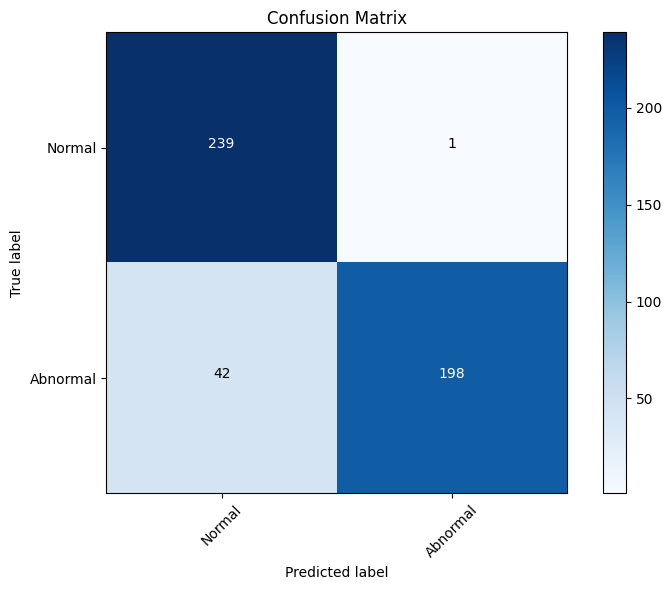

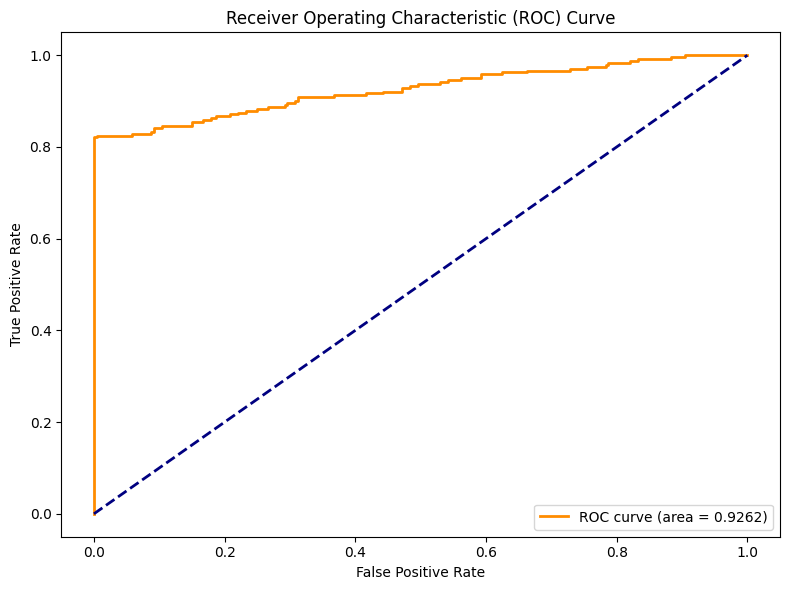

In [ ]:
conf_matrix = confusion_matrix(y_val, y_pred)

plt.figure(figsize=(8, 6))
plt.imshow(conf_matrix, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()
tick_marks = np.arange(2)
plt.xticks(tick_marks, ['Normal', 'Abnormal'], rotation=45)
plt.yticks(tick_marks, ['Normal', 'Abnormal'])

thresh = conf_matrix.max() / 2.
for i, j in np.ndindex(conf_matrix.shape):
    plt.text(j, i, format(conf_matrix[i, j], 'd'),
             horizontalalignment="center",
             color="white" if conf_matrix[i, j] > thresh else "black")

plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.tight_layout()
plt.savefig('confusion_matrix.png')
plt.show()

# Plot and Save ROC Curve if applicable
if len(np.unique(y_val)) > 1:
    fpr, tpr, _ = roc_curve(y_val, y_pred_prob)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.4f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.savefig('roc_curve.png')
    plt.show() 
